# 04 — Customer RFM Segmentation (Issue #8)

This notebook productionizes the RFM methodology finalized in Issues **#5** and **#15** on the latest `data/processed/cleaned_retail.csv` produced by the reviewed cleaning pipeline from Issue **#16**.

**Issue #8 objectives**

- calculate Recency, Frequency and Monetary for every eligible identified customer;
- apply the agreed percentile scoring and six-segment contract from Issue #15;
- validate RFM against the transaction-level population;
- export `data/processed/customer_segments.csv`;
- quantify customer count, revenue contribution and buying behavior by segment;
- create the required RFM/segment visualizations;
- provide data-backed insights for the P4 question about high-value and inactive customer groups.

**Contract reused without redefinition**

- Recency = calendar days from `ReferenceDate` to the latest valid purchase;
- `ReferenceDate` = one calendar day after the latest valid identified-customer purchase;
- Frequency = number of distinct valid `InvoiceNo` values;
- Monetary = sum of valid `Quantity × UnitPrice`;
- `Guest`/anonymous rows are excluded from customer RFM;
- R/F/M scoring uses tie-safe average percentile ranks (1–5);
- the allowed segments are exactly: Champions, Loyal Customers, At Risk, Potential Loyalists, Hibernating, Others;
- duplicate handling remains an upstream cleaning responsibility.


## 1. Setup and production paths

The notebook imports the reusable RFM engine from `src.feature_engineering`; it does **not** implement a second RFM algorithm.


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.set_option("display.max_columns", 40)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")


def find_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "src").exists():
            return candidate
    raise FileNotFoundError("Could not locate repository root containing src/.")


PROJECT_ROOT = find_project_root(Path.cwd().resolve())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.feature_engineering import (
    CUSTOMER_SEGMENTS_COLUMNS,
    audit_rfm_input,
    calculate_rfm,
    prepare_rfm_transactions,
)

DATA_PATH = PROJECT_ROOT / "data" / "processed" / "cleaned_retail.csv"
OUTPUT_PATH = PROJECT_ROOT / "data" / "processed" / "customer_segments.csv"
CHART_DIR = PROJECT_ROOT / "charts"
CHART_DIR.mkdir(parents=True, exist_ok=True)

ALLOWED_SEGMENTS = {
    "Champions",
    "Loyal Customers",
    "At Risk",
    "Potential Loyalists",
    "Hibernating",
    "Others",
}

print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATA_PATH:", DATA_PATH)
print("OUTPUT_PATH:", OUTPUT_PATH)
print("CHART_DIR:", CHART_DIR)


PROJECT_ROOT: /mnt/data/pds8_work/pds301m-ecommerce-analytics-develop
DATA_PATH: /mnt/data/pds8_work/pds301m-ecommerce-analytics-develop/data/processed/cleaned_retail.csv
OUTPUT_PATH: /mnt/data/pds8_work/pds301m-ecommerce-analytics-develop/data/processed/customer_segments.csv
CHART_DIR: /mnt/data/pds8_work/pds301m-ecommerce-analytics-develop/charts


## 2. Load the latest cleaned retail dataset

Issue #8 consumes the reviewed output from the upstream cleaning pipeline. No additional deduplication or cancellation-cleaning policy is introduced here.


In [2]:
assert DATA_PATH.exists(), f"Missing production dataset: {DATA_PATH}"

cleaned = pd.read_csv(
    DATA_PATH,
    dtype={"InvoiceNo": "string", "CustomerID": "string"},
    low_memory=False,
)

required_columns = {
    "InvoiceNo",
    "Quantity",
    "InvoiceDate",
    "UnitPrice",
    "CustomerID",
}
missing_columns = required_columns.difference(cleaned.columns)
assert not missing_columns, f"Missing required RFM columns: {sorted(missing_columns)}"

print(f"Loaded {len(cleaned):,} cleaned transaction rows.")
print("Columns:", cleaned.columns.tolist())
cleaned.head()


Loaded 524,878 cleaned transaction rows.
Columns: ['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country', 'Revenue', 'YearMonth']


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue,YearMonth
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30,2010-12
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010-12
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00,2010-12
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010-12
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010-12


## 3. Audit the RFM input population

The audit is descriptive and counts can overlap. `Guest` rows may legitimately remain in the cleaned transaction dataset for non-customer analyses, but they are not eligible for customer-level RFM.


In [3]:
rfm_audit = audit_rfm_input(cleaned)
audit_table = (
    pd.Series(rfm_audit, name="Rows")
    .rename_axis("Check")
    .reset_index()
)
audit_table


,Check,Rows
0,input_rows,524878
1,missing_invoice_rows,0
2,cancelled_rows,0
3,missing_customer_rows,0
4,anonymous_customer_rows,132186
5,missing_quantity_rows,0
6,nonnumeric_quantity_rows,0
7,nonpositive_quantity_rows,0
8,missing_unit_price_rows,0
9,nonnumeric_unit_price_rows,0


In [4]:
# The Issue #16 cleaned dataset should already satisfy core transaction validity rules.
assert rfm_audit["missing_invoice_rows"] == 0
assert rfm_audit["cancelled_rows"] == 0
assert rfm_audit["nonpositive_quantity_rows"] == 0
assert rfm_audit["nonpositive_unit_price_rows"] == 0
assert rfm_audit["invalid_invoice_date_rows"] == 0
assert rfm_audit["exact_duplicate_rows"] == 0

print("Upstream cleaning-contract checks passed.")


Upstream cleaning-contract checks passed.


## 4. Build the eligible identified-customer population

`prepare_rfm_transactions()` applies the Issue #15 eligibility contract, normalizes customer identifiers and recalculates transaction Revenue as `Quantity × UnitPrice`.


In [5]:
valid_transactions = prepare_rfm_transactions(cleaned)

population_summary = pd.Series({
    "Cleaned rows": len(cleaned),
    "RFM-eligible transaction rows": len(valid_transactions),
    "Identified customers": valid_transactions["CustomerID"].nunique(),
    "Distinct valid invoices": valid_transactions["InvoiceNo"].nunique(),
})
population_summary


Cleaned rows                     524878
RFM-eligible transaction rows    392692
Identified customers               4338
Distinct valid invoices           18532
dtype: int64

In [6]:
assert valid_transactions["CustomerID"].notna().all()
assert valid_transactions["CustomerID"].str.strip().ne("").all()
assert valid_transactions["CustomerID"].str.strip().str.casefold().ne("guest").all()
assert valid_transactions["InvoiceNo"].notna().all()
assert valid_transactions["InvoiceNo"].str.strip().ne("").all()
assert ~valid_transactions["InvoiceNo"].str.startswith("C", na=False).any()
assert valid_transactions["Quantity"].gt(0).all()
assert valid_transactions["UnitPrice"].gt(0).all()
assert valid_transactions["InvoiceDate"].notna().all()
assert valid_transactions["Revenue"].gt(0).all()

print("Eligible RFM population validation passed.")


Eligible RFM population validation passed.


## 5. Calculate production RFM and assign customer segments

The latest valid identified-customer purchase determines the single reference date used for all customers.


In [7]:
customer_segments, rfm_metadata = calculate_rfm(
    cleaned,
    return_metadata=True,
)

pd.Series({
    "valid_transaction_rows": rfm_metadata["valid_transaction_rows"],
    "customers": rfm_metadata["customers"],
    "invoices": rfm_metadata["invoices"],
    "last_valid_purchase": rfm_metadata["last_valid_purchase"],
    "reference_date": rfm_metadata["reference_date"],
})


valid_transaction_rows                 392692
customers                                4338
invoices                                18532
last_valid_purchase       2011-12-09 12:50:00
reference_date            2011-12-10 00:00:00
dtype: object

In [8]:
customer_segments.head(10)


,CustomerID,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_score,RFM_total,Segment,LastPurchaseDate,ReferenceDate
0,14646,2,73,"280,206.02",5,5,5,555,15,Champions,2011-12-08,2011-12-10
1,18102,1,60,"259,657.30",5,5,5,555,15,Champions,2011-12-09,2011-12-10
2,17450,9,46,"194,390.79",5,5,5,555,15,Champions,2011-12-01,2011-12-10
3,14911,2,201,"143,711.17",5,5,5,555,15,Champions,2011-12-08,2011-12-10
4,14156,10,55,"117,210.08",5,5,5,555,15,Champions,2011-11-30,2011-12-10
5,17511,3,31,"91,062.38",5,5,5,555,15,Champions,2011-12-07,2011-12-10
6,16684,5,28,"66,653.56",5,5,5,555,15,Champions,2011-12-05,2011-12-10
7,14096,5,17,"65,164.79",5,5,5,555,15,Champions,2011-12-05,2011-12-10
8,13694,4,50,"65,039.62",5,5,5,555,15,Champions,2011-12-06,2011-12-10
9,15311,1,91,"60,632.75",5,5,5,555,15,Champions,2011-12-09,2011-12-10


## 6. Validate customer-level RFM output

These checks enforce the production schema, customer uniqueness, score ranges, date rules and the six-segment contract from Issue #15.


In [9]:
assert customer_segments.columns.tolist() == CUSTOMER_SEGMENTS_COLUMNS
assert customer_segments["CustomerID"].notna().all()
assert customer_segments["CustomerID"].is_unique

assert customer_segments["Recency"].ge(1).all()
assert customer_segments["Frequency"].ge(1).all()
assert customer_segments["Monetary"].gt(0).all()

for score_column in ["R_score", "F_score", "M_score"]:
    assert customer_segments[score_column].between(1, 5).all()

assert customer_segments["RFM_score"].astype(str).str.fullmatch(r"[1-5]{3}").all()
assert customer_segments["RFM_total"].between(3, 15).all()
assert set(customer_segments["Segment"]).issubset(ALLOWED_SEGMENTS)
assert customer_segments["ReferenceDate"].nunique() == 1
assert (customer_segments["LastPurchaseDate"] <= customer_segments["ReferenceDate"]).all()

print("Production RFM schema and contract validation passed.")


Production RFM schema and contract validation passed.


## 7. Monetary reconciliation

Issue #8 requires total customer Monetary to reconcile to transaction Revenue for the exact RFM-eligible population. The comparison uses a small floating-point tolerance only.


In [10]:
expected_revenue = valid_transactions["Revenue"].sum()
actual_monetary = customer_segments["Monetary"].sum()
monetary_difference = actual_monetary - expected_revenue

reconciliation = pd.DataFrame({
    "Metric": [
        "Eligible transaction Revenue",
        "Customer RFM Monetary",
        "Difference",
    ],
    "Value": [
        expected_revenue,
        actual_monetary,
        monetary_difference,
    ],
})
reconciliation


,Metric,Value
0,Eligible transaction Revenue,"8,887,208.89"
1,Customer RFM Monetary,"8,887,208.89"
2,Difference,-0.00


In [11]:
assert np.isclose(
    actual_monetary,
    expected_revenue,
    rtol=0,
    atol=1e-6,
)
print("Monetary reconciliation passed.")


Monetary reconciliation passed.


## 8. Verify representative customers against transactions

This checks the required cases using actual production rows: a one-invoice customer and a multi-invoice customer. Frequency, Monetary, last purchase and Recency are recomputed independently from their eligible transactions.


In [12]:
def verify_customer(customer_id: str) -> pd.Series:
    tx = valid_transactions.loc[
        valid_transactions["CustomerID"].eq(str(customer_id))
    ].copy()
    rfm_row = customer_segments.loc[
        customer_segments["CustomerID"].eq(str(customer_id))
    ].iloc[0]

    expected_frequency = int(tx["InvoiceNo"].nunique())
    expected_monetary = float(tx["Revenue"].sum())
    expected_last_purchase = tx["InvoiceDate"].max().normalize()
    reference_date = pd.Timestamp(rfm_row["ReferenceDate"]).normalize()
    expected_recency = int((reference_date - expected_last_purchase).days)

    return pd.Series({
        "CustomerID": str(customer_id),
        "TransactionRows": len(tx),
        "ExpectedFrequency": expected_frequency,
        "RFMFrequency": int(rfm_row["Frequency"]),
        "ExpectedMonetary": expected_monetary,
        "RFMMonetary": float(rfm_row["Monetary"]),
        "ExpectedLastPurchase": expected_last_purchase,
        "RFMLastPurchase": pd.Timestamp(rfm_row["LastPurchaseDate"]),
        "ExpectedRecency": expected_recency,
        "RFMRecency": int(rfm_row["Recency"]),
    })


one_invoice_customer = (
    customer_segments.loc[customer_segments["Frequency"].eq(1), "CustomerID"].iloc[0]
)
multi_invoice_customer = (
    customer_segments.sort_values("Frequency", ascending=False)["CustomerID"].iloc[0]
)

verification = pd.DataFrame([
    verify_customer(one_invoice_customer),
    verify_customer(multi_invoice_customer),
])
verification


,CustomerID,TransactionRows,ExpectedFrequency,RFMFrequency,ExpectedMonetary,RFMMonetary,ExpectedLastPurchase,RFMLastPurchase,ExpectedRecency,RFMRecency
0,15195,1,1,1,"3,861.00","3,861.00",2011-12-07,2011-12-07,3,3
1,12748,4412,209,209,"33,053.19","33,053.19",2011-12-09,2011-12-09,1,1


In [13]:
assert (verification["ExpectedFrequency"] == verification["RFMFrequency"]).all()
assert np.allclose(verification["ExpectedMonetary"], verification["RFMMonetary"])
assert (verification["ExpectedLastPurchase"] == verification["RFMLastPurchase"]).all()
assert (verification["ExpectedRecency"] == verification["RFMRecency"]).all()

# Demonstrate that at least one valid invoice contains multiple product rows.
invoice_line_counts = valid_transactions.groupby("InvoiceNo").size().sort_values(ascending=False)
multi_line_invoice = invoice_line_counts.index[0]
multi_line_rows = valid_transactions.loc[
    valid_transactions["InvoiceNo"].eq(multi_line_invoice)
]
assert len(multi_line_rows) > 1

print("Representative customer and multi-line invoice checks passed.")
print("Example multi-line invoice:", multi_line_invoice, "rows:", len(multi_line_rows))


Representative customer and multi-line invoice checks passed.
Example multi-line invoice: 576339 rows: 542


## 9. Export `customer_segments.csv`

The repository ignores `data/processed/*` because processed datasets are generated artifacts. The notebook nevertheless creates and validates the required Issue #8 deliverable locally.


In [14]:
OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)

export_df = customer_segments.copy()
export_df["LastPurchaseDate"] = pd.to_datetime(export_df["LastPurchaseDate"]).dt.strftime("%Y-%m-%d")
export_df["ReferenceDate"] = pd.to_datetime(export_df["ReferenceDate"]).dt.strftime("%Y-%m-%d")
export_df.to_csv(OUTPUT_PATH, index=False)

export_check = pd.read_csv(
    OUTPUT_PATH,
    dtype={"CustomerID": "string", "RFM_score": "string"},
)

assert export_check.columns.tolist() == CUSTOMER_SEGMENTS_COLUMNS
assert len(export_check) == len(customer_segments)
assert export_check["CustomerID"].is_unique

print(f"Exported and validated {len(export_check):,} customers -> {OUTPUT_PATH}")


Exported and validated 4,338 customers -> /mnt/data/pds8_work/pds301m-ecommerce-analytics-develop/data/processed/customer_segments.csv


## 10. Customer and revenue analysis by segment

The summary reports customer count/share, segment revenue/share, average revenue per customer and central RFM behavior. `Revenue` at segment level is the sum of customer Monetary, so it reconciles to the eligible transaction population.


In [15]:
segment_summary = (
    customer_segments
    .groupby("Segment", as_index=False)
    .agg(
        CustomerCount=("CustomerID", "nunique"),
        Revenue=("Monetary", "sum"),
        AvgRevenuePerCustomer=("Monetary", "mean"),
        AvgRecency=("Recency", "mean"),
        MedianRecency=("Recency", "median"),
        AvgFrequency=("Frequency", "mean"),
        MedianFrequency=("Frequency", "median"),
        AvgMonetary=("Monetary", "mean"),
    )
)

segment_summary["CustomerShare"] = (
    segment_summary["CustomerCount"] / segment_summary["CustomerCount"].sum()
)
segment_summary["RevenueShare"] = (
    segment_summary["Revenue"] / segment_summary["Revenue"].sum()
)

segment_summary = segment_summary.sort_values(
    "Revenue", ascending=False
).reset_index(drop=True)

summary_display = segment_summary.copy()
summary_display["CustomerSharePct"] = summary_display["CustomerShare"] * 100
summary_display["RevenueSharePct"] = summary_display["RevenueShare"] * 100
summary_display = summary_display.drop(columns=["CustomerShare", "RevenueShare"])
summary_display


,Segment,CustomerCount,Revenue,AvgRevenuePerCustomer,AvgRecency,MedianRecency,AvgFrequency,MedianFrequency,AvgMonetary,CustomerSharePct,RevenueSharePct
0,Champions,911,"5,676,143.38","6,230.67",12.85,10.00,11.50,8.00,"6,230.67",21.00,63.87
1,At Risk,938,"1,161,835.10","1,238.63",161.11,142.50,2.80,2.00,"1,238.63",21.62,13.07
2,Loyal Customers,381,"823,495.76","2,161.41",39.50,41.00,5.80,5.00,"2,161.41",8.78,9.27
3,Potential Loyalists,484,"583,120.23","1,204.79",16.93,18.00,2.42,2.00,"1,204.79",11.16,6.56
4,Others,835,"465,436.79",557.41,43.26,45.00,1.51,1.00,557.41,19.25,5.24
5,Hibernating,789,"177,177.63",224.56,230.05,240.00,1.00,1.00,224.56,18.19,1.99


In [16]:
assert segment_summary["CustomerCount"].sum() == len(customer_segments)
assert np.isclose(
    segment_summary["Revenue"].sum(),
    customer_segments["Monetary"].sum(),
    rtol=0,
    atol=1e-6,
)
assert np.isclose(segment_summary["CustomerShare"].sum(), 1.0)
assert np.isclose(segment_summary["RevenueShare"].sum(), 1.0)

print("Segment aggregation reconciliation passed.")


Segment aggregation reconciliation passed.


## 11. RFM distributions

Frequency and Monetary are strongly right-skewed. Their charts are clipped at the 99th percentile **for visualization only**. The underlying production values and scoring remain unchanged.


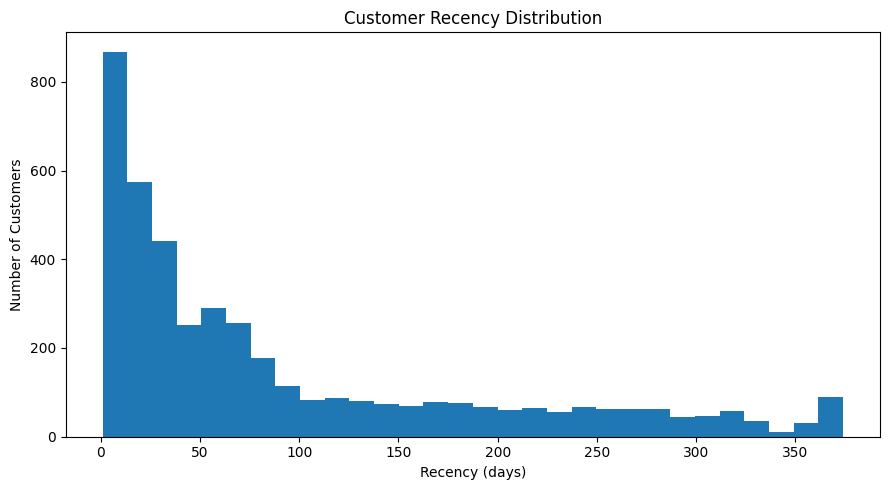

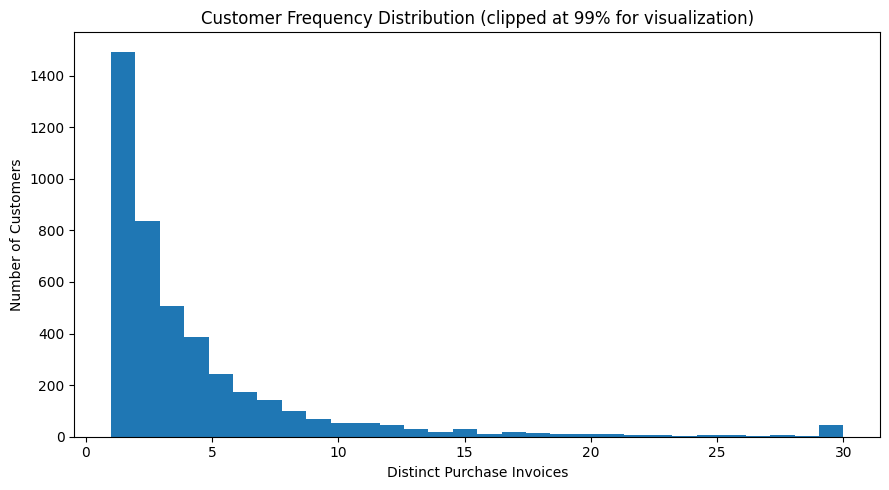

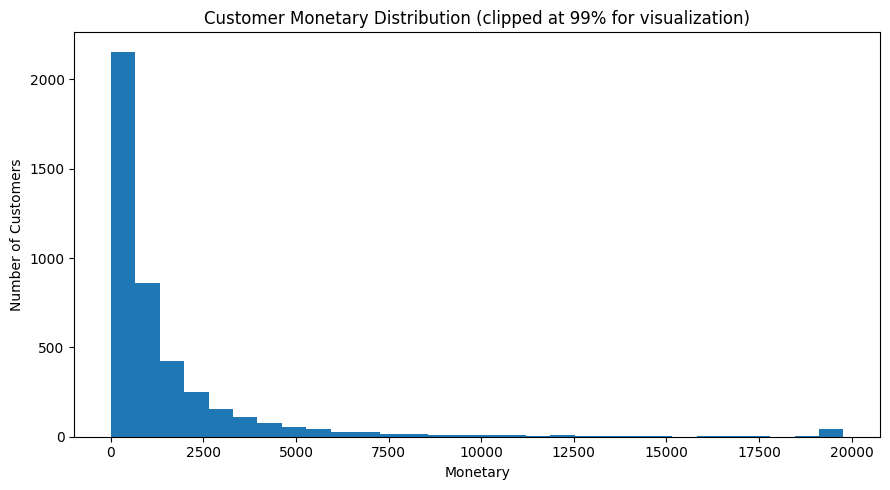

In [17]:
def save_histogram(series, title, xlabel, filename, *, upper_quantile=None):
    plot_series = series
    suffix = ""
    if upper_quantile is not None:
        upper = series.quantile(upper_quantile)
        plot_series = series.clip(upper=upper)
        suffix = f" (clipped at {upper_quantile:.0%} for visualization)"

    fig, ax = plt.subplots(figsize=(9, 5))
    ax.hist(plot_series, bins=30)
    ax.set_title(title + suffix)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Number of Customers")
    fig.tight_layout()
    path = CHART_DIR / filename
    fig.savefig(path, dpi=150, bbox_inches="tight")
    plt.show()
    return path


recency_chart = save_histogram(
    customer_segments["Recency"],
    "Customer Recency Distribution",
    "Recency (days)",
    "rfm_recency_distribution.png",
)

frequency_chart = save_histogram(
    customer_segments["Frequency"],
    "Customer Frequency Distribution",
    "Distinct Purchase Invoices",
    "rfm_frequency_distribution.png",
    upper_quantile=0.99,
)

monetary_chart = save_histogram(
    customer_segments["Monetary"],
    "Customer Monetary Distribution",
    "Monetary",
    "rfm_monetary_distribution.png",
    upper_quantile=0.99,
)


## 12. Customer count and revenue by segment


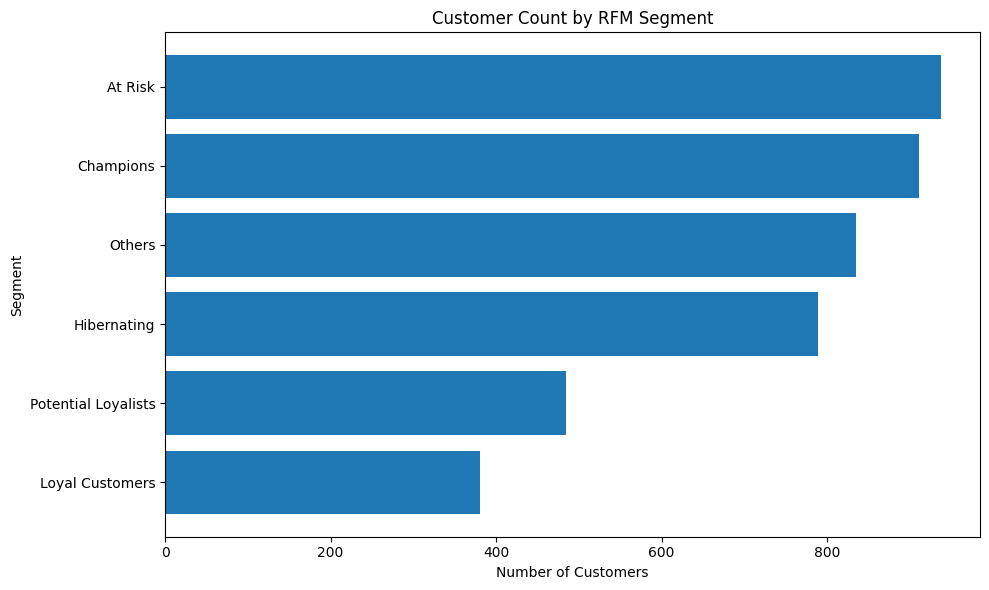

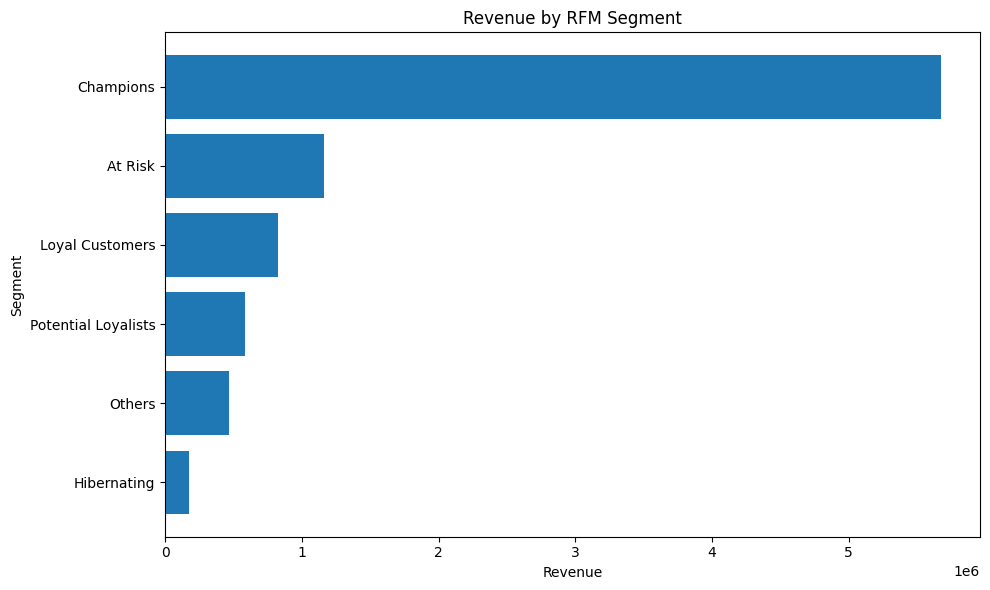

In [18]:
customer_count_plot = segment_summary.sort_values("CustomerCount", ascending=True)
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(customer_count_plot["Segment"], customer_count_plot["CustomerCount"])
ax.set_title("Customer Count by RFM Segment")
ax.set_xlabel("Number of Customers")
ax.set_ylabel("Segment")
fig.tight_layout()
customer_count_chart = CHART_DIR / "rfm_customer_count_by_segment.png"
fig.savefig(customer_count_chart, dpi=150, bbox_inches="tight")
plt.show()

revenue_plot = segment_summary.sort_values("Revenue", ascending=True)
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(revenue_plot["Segment"], revenue_plot["Revenue"])
ax.set_title("Revenue by RFM Segment")
ax.set_xlabel("Revenue")
ax.set_ylabel("Segment")
fig.tight_layout()
revenue_chart = CHART_DIR / "rfm_revenue_by_segment.png"
fig.savefig(revenue_chart, dpi=150, bbox_inches="tight")
plt.show()


## 13. Quantitative business insights

The code below derives insight text from the current data rather than hard-coding historical values. This keeps the interpretation synchronized when the cleaned dataset is regenerated.


In [19]:
summary_indexed = segment_summary.set_index("Segment")

champions = summary_indexed.loc["Champions"]
at_risk = summary_indexed.loc["At Risk"]
hibernating = summary_indexed.loc["Hibernating"]

print(
    "Champions: "
    f"{champions['CustomerShare'] * 100:.1f}% of customers, "
    f"{champions['RevenueShare'] * 100:.1f}% of revenue, "
    f"average Frequency {champions['AvgFrequency']:.2f}, "
    f"average Recency {champions['AvgRecency']:.2f} days."
)

print(
    "At Risk: "
    f"{at_risk['CustomerShare'] * 100:.1f}% of customers, "
    f"{at_risk['RevenueShare'] * 100:.1f}% of revenue, "
    f"average Recency {at_risk['AvgRecency']:.2f} days."
)

print(
    "Hibernating: "
    f"{hibernating['CustomerShare'] * 100:.1f}% of customers, "
    f"{hibernating['RevenueShare'] * 100:.1f}% of revenue, "
    f"average Recency {hibernating['AvgRecency']:.2f} days, "
    f"average Frequency {hibernating['AvgFrequency']:.2f}."
)


Champions: 21.0% of customers, 63.9% of revenue, average Frequency 11.50, average Recency 12.85 days.
At Risk: 21.6% of customers, 13.1% of revenue, average Recency 161.11 days.
Hibernating: 18.2% of customers, 2.0% of revenue, average Recency 230.05 days, average Frequency 1.00.


### Interpretation

- **Champions** are the primary high-value segment when they lead revenue contribution while also exhibiting recent and frequent purchase behavior. They are the strongest retention/VIP-priority group.
- **At Risk** deserves re-engagement attention when its Recency is materially higher while the segment still retains meaningful historical revenue contribution. The label describes RFM behavior; it is **not** a churn prediction.
- **Hibernating** represents customers with long purchase inactivity and low repeat behavior under the agreed rules. Their revenue contribution should be interpreted together with their customer share before allocating campaign budget.
- Segment decisions are descriptive and relative to this dataset's RFM distribution; they should not be interpreted as causal or fraud/churn labels.


## 14. Issue #8 Acceptance Criteria verification

The final cell turns the Issue acceptance criteria into executable checks. The notebook is considered complete only if every check passes.


In [20]:
required_charts = [
    recency_chart,
    frequency_chart,
    monetary_chart,
    customer_count_chart,
    revenue_chart,
]

acceptance_checks = {
    "customer_segments_exported": OUTPUT_PATH.exists(),
    "schema_matches_contract": customer_segments.columns.tolist() == CUSTOMER_SEGMENTS_COLUMNS,
    "customer_ids_are_unique": bool(customer_segments["CustomerID"].is_unique),
    "monetary_reconciles_to_eligible_revenue": bool(np.isclose(
        customer_segments["Monetary"].sum(),
        valid_transactions["Revenue"].sum(),
        rtol=0,
        atol=1e-6,
    )),
    "segment_labels_match_issue15_contract": set(customer_segments["Segment"]).issubset(ALLOWED_SEGMENTS),
    "segment_customer_count_reconciles": int(segment_summary["CustomerCount"].sum()) == len(customer_segments),
    "segment_revenue_reconciles": bool(np.isclose(
        segment_summary["Revenue"].sum(),
        customer_segments["Monetary"].sum(),
        rtol=0,
        atol=1e-6,
    )),
    "revenue_share_sums_to_one": bool(np.isclose(segment_summary["RevenueShare"].sum(), 1.0)),
    "required_charts_exist": all(path.exists() for path in required_charts),
}

acceptance_table = pd.Series(acceptance_checks, name="Passed").rename_axis("Acceptance Check").reset_index()
display(acceptance_table)

failed_checks = [name for name, passed in acceptance_checks.items() if not passed]
assert not failed_checks, f"Failed Issue #8 Acceptance Criteria: {failed_checks}"

print("All Issue #8 Acceptance Criteria passed.")
print(f"Production customers: {len(customer_segments):,}")
print(f"Eligible Revenue / Monetary: {actual_monetary:,.3f}")
print(f"Reference date: {pd.Timestamp(rfm_metadata['reference_date']).date()}")


,Acceptance Check,Passed
0,customer_segments_exported,True
1,schema_matches_contract,True
2,customer_ids_are_unique,True
3,monetary_reconciles_to_eligible_revenue,True
4,segment_labels_match_issue15_contract,True
5,segment_customer_count_reconciles,True
6,segment_revenue_reconciles,True
7,revenue_share_sums_to_one,True
8,required_charts_exist,True


All Issue #8 Acceptance Criteria passed.
Production customers: 4,338
Eligible Revenue / Monetary: 8,887,208.894
Reference date: 2011-12-10
